# libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Dilation and Erosion

In [1]:
def dilate(image, structuring_element):
    structuring_element_rows, structuring_element_cols = structuring_element.shape
    structuring_element_center = (structuring_element_rows // 2, structuring_element_cols // 2)
    
    pad_top, pad_left = structuring_element_center
    pad_bottom = structuring_element_rows - pad_top - 1
    pad_right = structuring_element_cols - pad_left - 1
    
    padded_image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)
                
    output_image = np.zeros_like(image)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            region = padded_image[row:row+structuring_element_rows, col:col+structuring_element_cols]
            if np.any(np.logical_and(region > 0, structuring_element > 0)):
                output_image[row, col] = 255

    return output_image

In [3]:
def erode(image, structuring_element):
    structuring_element_rows, structuring_element_cols = structuring_element.shape
    structuring_element_center = (structuring_element_rows // 2, structuring_element_cols // 2)
    
    pad_top, pad_left = structuring_element_center
    pad_bottom = structuring_element_rows - pad_top - 1
    pad_right = structuring_element_cols - pad_left - 1
    
    padded_image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)
    
    output_image = np.zeros_like(image) 

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            region = padded_image[row:row+structuring_element_rows, col:col+structuring_element_cols]
            if np.all(region[structuring_element > 0] > 0):
                output_image[row, col] = 255 

    return output_image

## Noise Reduction

In [12]:
path = "Noisy_image.png"  
noisy_image = cv2.imread(path, 0)

structuring_element = np.ones((7, 7), np.uint8) 

eroded = erode(noisy_image, structuring_element) 

cleaned = dilate(eroded, structuring_element)

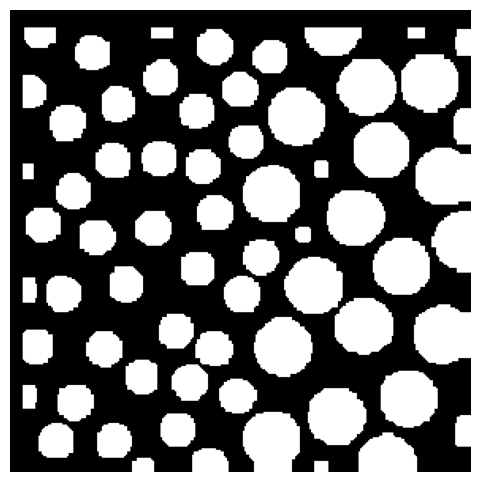

In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(cleaned, cmap='gray')
plt.axis('off')
plt.show()

## Parallel Vertical Lines

In [8]:
image_path = "OpenCV.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

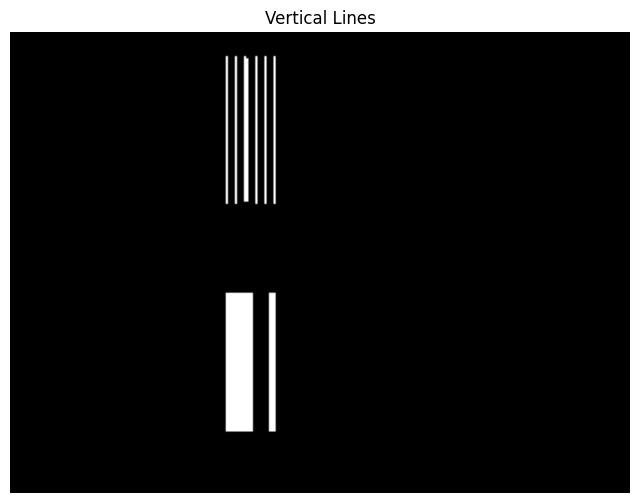

In [13]:
kernel_1x25 = np.ones((25, 1), np.uint8) 
kernel_3x25 = np.ones((25, 3), np.uint8) 

eroded_1 = erode(binary_image, kernel_1x25) 
dilated_1 = dilate(eroded_1, kernel_1x25) 

eroded_2 = erode(binary_image, kernel_3x25) 
dilated_2 = dilate(eroded_2, kernel_3x25) 

result = dilated_1 

plt.figure(figsize=(8, 6))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.title("Vertical Lines")
plt.show()

## Parallel Horizontal Lines

In [14]:
_, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

horizontal_kernel = np.ones((1, 25), np.uint8) 

eroded = erode(binary_image, horizontal_kernel) 
result = dilate(eroded, horizontal_kernel)

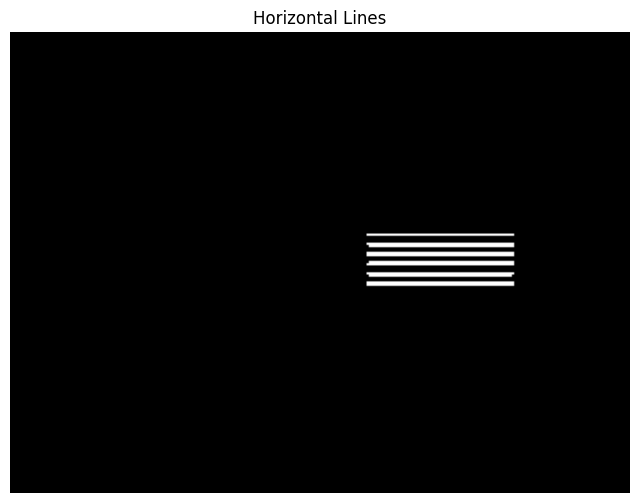

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.title("Horizontal Lines")
plt.show()

## Edge Detecting

In [ ]:
image_path = "leaf.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Could not load '{image_path}'. Check the path!")

_, binary_image = cv2.threshold(image, 220, 255, cv2.THRESH_BINARY)

kernel = np.ones((3, 3), np.uint8) 

dilated_image = dilate(binary_image, kernel) 

edges = cv2.absdiff(dilated_image, binary_image)

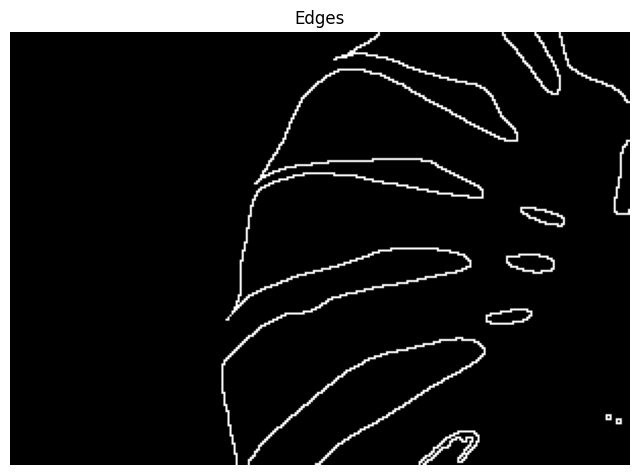

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.title("Edges")
plt.show()